In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [2]:
#collecting data

In [3]:
from sklearn.preprocessing import MinMaxScaler

In [4]:
now =datetime.now()
start=datetime(now.year-10,now.month,now.day)
end=now
ticker='AAPL'
df=yf.download(ticker,start,end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-01,22.768080,22.822435,22.063725,22.115817,201628400
2016-03-02,22.817907,22.849614,22.566514,22.763553,132678400
2016-03-03,22.987764,23.035325,22.749959,22.779403,147822800
2016-03-04,23.329754,23.497349,22.958326,23.184807,184220400
2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600
...,...,...,...,...,...
2026-02-23,266.179993,269.429993,263.380005,263.489990,37308200
2026-02-24,272.140015,274.890015,267.709991,267.859985,47014600


In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2514, 5)

In [7]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,117.926498,119.104325,116.641600,117.822196,9.926984e+07
std,74.628506,75.358294,73.846590,74.573784,5.579081e+07
min,20.584816,20.887872,20.386579,20.507347,1.791060e+07
25%,42.980449,43.339344,42.577715,42.991815,6.016160e+07
50%,123.761200,125.050861,122.721294,123.919347,8.737440e+07
75%,174.317070,175.918453,172.200123,174.217468,1.212258e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [9]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-01,22.768080,22.822435,22.063725,22.115817,201628400
2016-03-02,22.817907,22.849614,22.566514,22.763553,132678400
2016-03-03,22.987764,23.035325,22.749959,22.779403,147822800
2016-03-04,23.329754,23.497349,22.958326,23.184807,184220400
2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600


In [10]:
df=df.reset_index()

In [11]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-03-01,22.768080,22.822435,22.063725,22.115817,201628400
1,2016-03-02,22.817907,22.849614,22.566514,22.763553,132678400
2,2016-03-03,22.987764,23.035325,22.749959,22.779403,147822800
3,2016-03-04,23.329754,23.497349,22.958326,23.184807,184220400
4,2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600


Text(0, 0.5, 'close price')

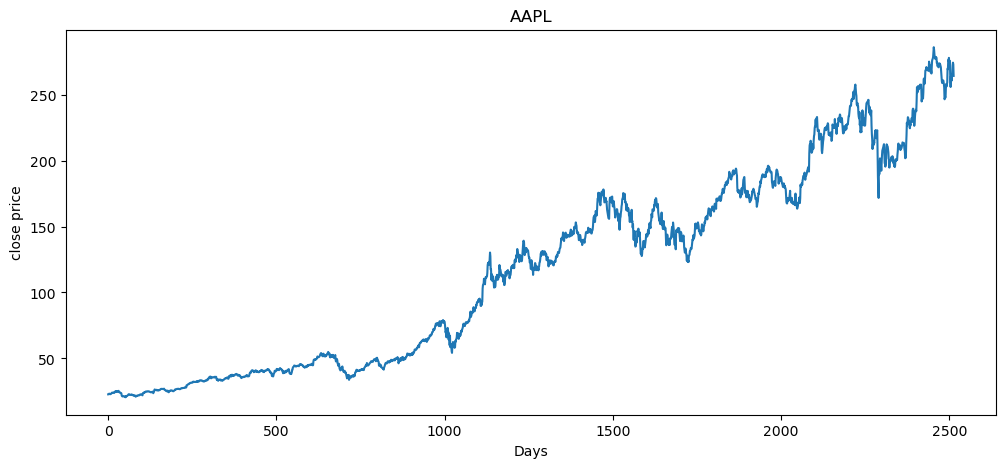

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('close price')

In [13]:
df[('MA_100', 'AAPL')] = df[('Close', 'AAPL')].rolling(100).mean()
df[('MA_200', 'AAPL')] = df[('Close', 'AAPL')].rolling(200).mean()
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-03-01,22.768080,22.822435,22.063725,22.115817,201628400,NaN,NaN
1,2016-03-02,22.817907,22.849614,22.566514,22.763553,132678400,NaN,NaN
2,2016-03-03,22.987764,23.035325,22.749959,22.779403,147822800,NaN,NaN
3,2016-03-04,23.329754,23.497349,22.958326,23.184807,184220400,NaN,NaN
4,2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600,NaN,NaN
...,...,...,...,...,...,...,...,...
2509,2026-02-23,266.179993,269.429993,263.380005,263.489990,37308200,265.898141,241.079698
2510,2026-02-24,272.140015,274.890015,267.709991,267.859985,47014600,266.078086,241.463407
2511,2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300,266.270745,241.851392


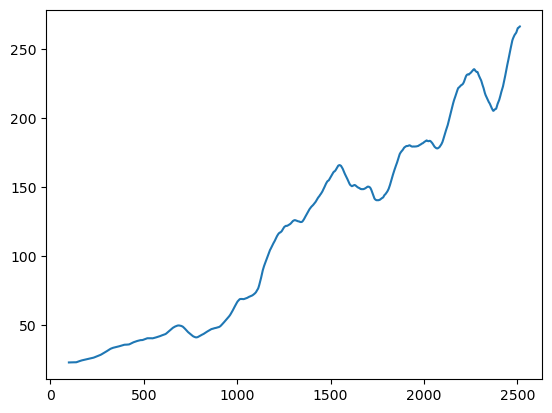

In [14]:
plt.plot(df['MA_100'])

Text(0, 0.5, 'close price')

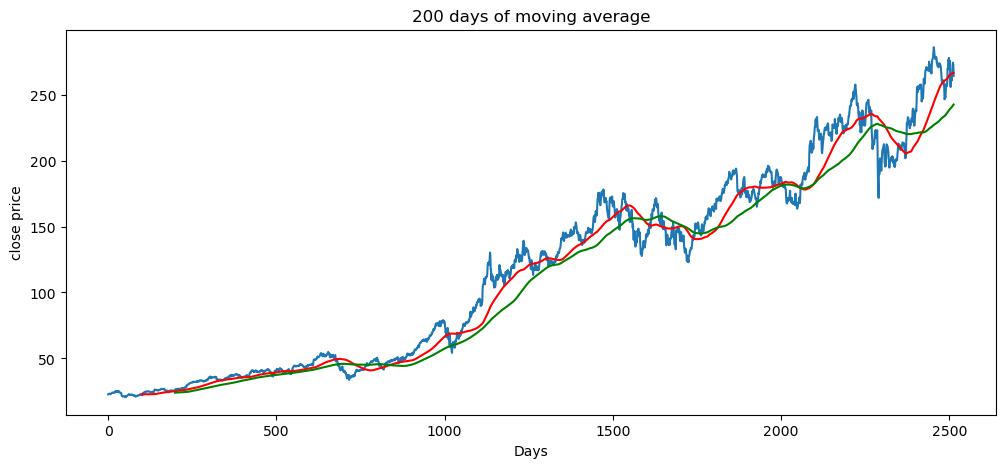

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'],'r')
plt.plot(df['MA_200'],'g')
plt.title('200 days of moving average')
plt.xlabel('Days')
plt.ylabel('close price')

In [16]:
df['Percentage_change']=df.Close.pct_change()
df[['Close','Percentage_change']]

Price,Close,Percentage_change
Ticker,AAPL,
0,22.768080,NaN
1,22.817907,0.002188
2,22.987764,0.007444
3,23.329754,0.014877
4,23.071566,-0.011067
...,...,...
2509,266.179993,0.006047
2510,272.140015,0.022391
2511,274.230011,0.007680


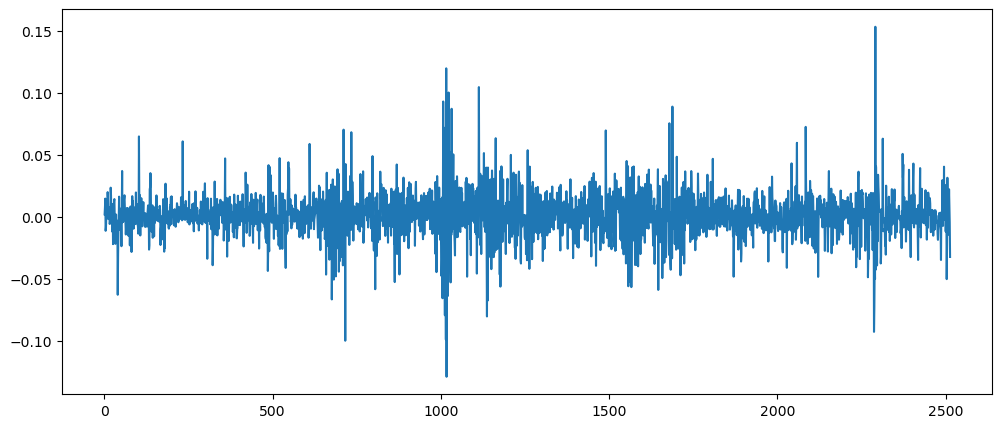

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage_change'])

In [ ]:
data_training = pd.DataFrame(df.Close[0:int(len(df) * 0.7)])
data_testing=pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_testing)data_training = pd.DataFrame(df.Close[0:int(len(df) * 0.7)])
data_testing=pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_testing)

Ticker        AAPL
1759    144.614944
1760    145.807678
1761    145.304947
1762    143.234909
1763    143.826385
...            ...
2509    266.179993
2510    272.140015
2511    274.230011
2512    272.950012
2513    264.179993

[755 rows x 1 columns]


In [19]:
scaler=MinMaxScaler(feature_range=(0,1))
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.01386033],
       [0.01417666],
       [0.01525499],
       ...,
       [0.79847489],
       [0.80116584],
       [0.80423215]])

In [20]:
x_train = []
y_train = []

for i in range(100, data_training.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i])

In [21]:
x_train,y_train=np.array(x_train), np.array(y_train)

In [22]:
x_train

array([[[0.01386033],
        [0.01417666],
        [0.01525499],
        ...,
        [0.01378566],
        [0.01391583],
        [0.01314919]],

       [[0.01417666],
        [0.01525499],
        [0.01742609],
        ...,
        [0.01391583],
        [0.01314919],
        [0.01203529]],

       [[0.01525499],
        [0.01742609],
        [0.015787  ],
        ...,
        [0.01314919],
        [0.01203529],
        [0.01012586]],

       ...,

       [[0.81598224],
        [0.80400537],
        [0.75809441],
        ...,
        [0.84134086],
        [0.83120316],
        [0.82394405]],

       [[0.80400537],
        [0.75809441],
        [0.73139628],
        ...,
        [0.83120316],
        [0.82394405],
        [0.79847489]],

       [[0.75809441],
        [0.73139628],
        [0.75790745],
        ...,
        [0.82394405],
        [0.79847489],
        [0.80116584]]])

In [23]:
y_train

array([[0.01203529],
       [0.01012586],
       [0.00915667],
       ...,
       [0.79847489],
       [0.80116584],
       [0.80423215]])

In [48]:
import tensorflow as tf


In [54]:
from keras.models import Sequential
from keras.layers import Dense ,LSTM,Input

In [60]:
model=Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

In [62]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0410
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 6.5959e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 6.4864e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 6.0471e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 5.8041e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 7.7133e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 5.4747e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 5.7345e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 5.0727e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 5.2676e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 5.6088e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 5.0569e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 5.6688e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 5.0901e-04
Epoch 15/50
52/52 ━

In [64]:
model.save('stock_prediction_model.keras')

In [66]:
data_testing

Ticker,AAPL
1759,144.614944
1760,145.807678
1761,145.304947
1762,143.234909
1763,143.826385
...,...
2509,266.179993
2510,272.140015
2511,274.230011
2512,272.950012


In [68]:
past_100_days=data_training.tail(100)

In [70]:
past_100_days

Ticker,AAPL
1659,135.793518
1660,139.969528
1661,143.556000
1662,143.850739
1663,142.897644
...,...
1754,151.514984
1755,150.371536
1756,146.359665
1757,146.783539


In [76]:
final_df=pd.concat([past_100_days,data_testing],ignore_index=True)

In [78]:
input_data=scaler.fit_transform(final_df)
input_data

array([[7.82603897e-02],
       [1.03899644e-01],
       [1.25919335e-01],
       [1.27728929e-01],
       [1.21877260e-01],
       [8.96622549e-02],
       [9.16530330e-02],
       [8.29660270e-02],
       [7.91050417e-02],
       [1.07157306e-01],
       [7.93463709e-02],
       [1.03658315e-01],
       [1.11742091e-01],
       [1.12405747e-01],
       [1.09570504e-01],
       [1.32977838e-01],
       [1.46128871e-01],
       [1.63563496e-01],
       [1.45525548e-01],
       [1.18076607e-01],
       [1.84074881e-01],
       [1.69596444e-01],
       [1.53368090e-01],
       [1.19464249e-01],
       [8.23627978e-02],
       [8.07312029e-02],
       [8.39942990e-02],
       [8.74990052e-02],
       [5.95212193e-02],
       [1.32034350e-01],
       [1.49135087e-01],
       [1.40554505e-01],
       [1.51189570e-01],
       [1.43636417e-01],
       [1.55298816e-01],
       [1.58743003e-01],
       [1.38922910e-01],
       [1.52035908e-01],
       [1.57413913e-01],
       [1.39527170e-01],


In [80]:
x_test=[]
y_test=[]
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [82]:
x_test,y_test=np.array(x_test),np.array(y_test)

In [84]:
y_predicted=model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


In [88]:
y_predicted=scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [90]:
y_test

array([144.61494446, 145.80767822, 145.3049469 , 143.23490906,
       143.8263855 , 148.8732605 , 151.63327026, 149.43513489,
       150.6869812 , 148.43954468, 146.37939453, 148.32125854,
       150.41099548, 150.80526733, 153.62442017, 152.78656006,
       155.15229797, 157.00546265, 155.57617188, 156.66046143,
       157.96162415, 156.01971436, 155.39872742, 158.47416687,
       160.04147339, 162.54519653, 163.79707336, 163.26473999,
       161.42146301, 162.30862427, 159.71618652, 158.50372314,
       157.81376648, 163.19577026, 162.85076904, 162.8704834 ,
       164.09274292, 165.2361908 , 164.2702179 , 162.66346741,
       162.96907043, 161.43133545, 161.42146301, 166.00508118,
       167.25691223, 167.16821289, 166.13322449, 165.05879211,
       163.42248535, 171.09138489, 171.0223999 , 169.3170929 ,
       171.08151245, 171.26881409, 170.34095764, 169.84742737,
       169.84742737, 170.4593811 , 172.78892517, 172.89750671,
       171.94989014, 169.3440094 , 169.62039185, 170.75

In [92]:
y_predicted

array([148.0264 , 146.85593, 146.32484, 145.9422 , 145.0989 , 144.5815 ,
       145.81001, 147.98155, 149.08675, 150.00786, 149.85529, 148.84296,
       148.53053, 149.1173 , 149.88474, 151.39426, 152.34238, 153.65707,
       155.24406, 155.89445, 156.49602, 157.30898, 157.21378, 156.74713,
       157.40112, 158.61049, 160.45328, 162.2708 , 163.26187, 163.0396 ,
       162.95578, 161.92708, 160.64304, 159.49326, 160.70978, 161.8498 ,
       162.64667, 163.54994, 164.5641 , 164.85889, 164.2968 , 163.872  ,
       163.02193, 162.40051, 163.75177, 165.48277, 166.68141, 166.94872,
       166.50792, 165.44043, 167.60123, 169.51811, 170.07152, 170.87935,
       171.45042, 171.37288, 171.00063, 170.70003, 170.76317, 171.81456,
       172.67966, 172.80594, 171.67725, 170.8772 , 170.86559, 171.98036,
       173.64304, 174.75732, 176.54277, 178.06548, 178.33511, 178.1144 ,
       177.26521, 177.82588, 178.51933, 180.21721, 181.15723, 181.88728,
       183.16934, 183.46663, 183.52774, 183.01407, 

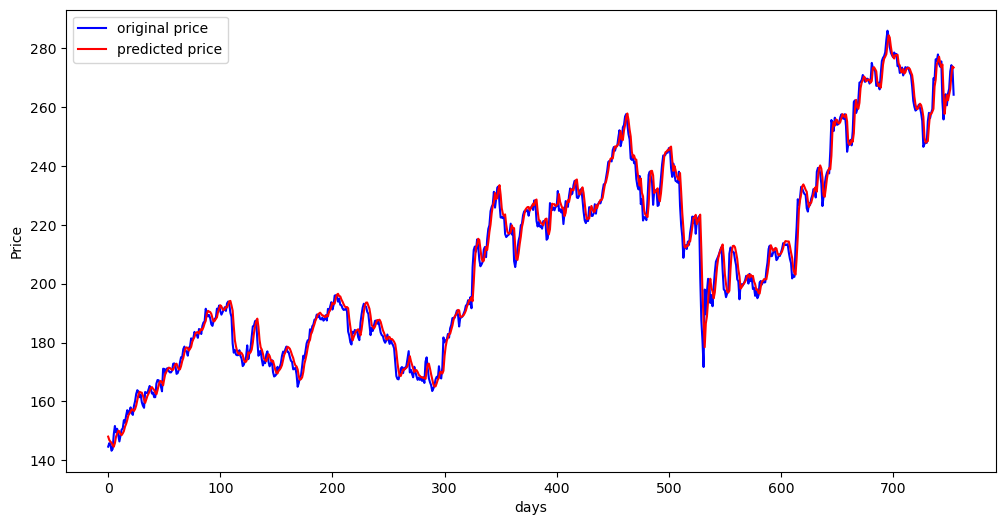

In [94]:
plt.figure(figsize=(12,6))
plt.plot(y_test,color='b',label="original price")
plt.plot(y_predicted,color='r',label="predicted price")
plt.xlabel("days")
plt.ylabel("Price")
plt.legend()

(190.0, 300.0)

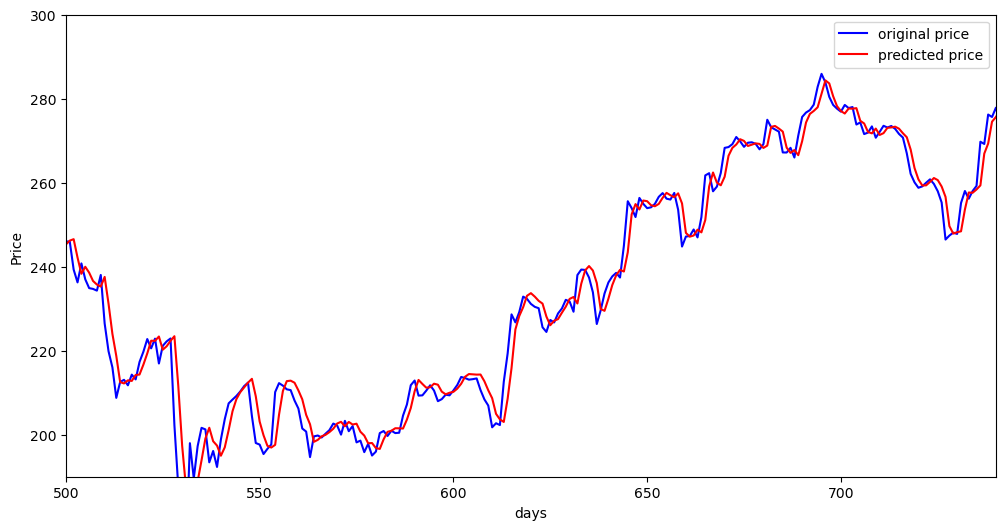

In [96]:
plt.figure(figsize=(12,6))
plt.plot(y_test,color='b',label="original price")
plt.plot(y_predicted,color='r',label="predicted price")
plt.xlabel("days")
plt.ylabel("Price")
plt.legend()
plt.xlim(500,740)
plt.ylim(190,300)

In [106]:
from sklearn.metrics import mean_squared_error,r2_score

In [102]:
mse=mean_squared_error(y_test,y_predicted)
print(f"Mean Squared error (MSE): {mse}")

Mean Squared error (MSE): 14.841276019310818


In [104]:
rmse=np.sqrt(mse)
print(f"Root Mean Squared error (RMSE): {rmse}")

Root Mean Squared error (RMSE): 3.85243767234602


In [108]:
r2=r2_score(y_test,y_predicted)
print(f"r2 score: {r2}")

r2 score: 0.987032805861103
